
📊 STATISTIQUES DATASET
─────────────────────────────────────────────
  Total images          : 13847
  Images masquées       : 6350
  Images non masquées   : 7497
  Moy images/personne   : 16.0
  Min images/personne   : 5
  Max images/personne   : 30
  Personnes < 5 images  : 0
  Personnes < 10 images : 300


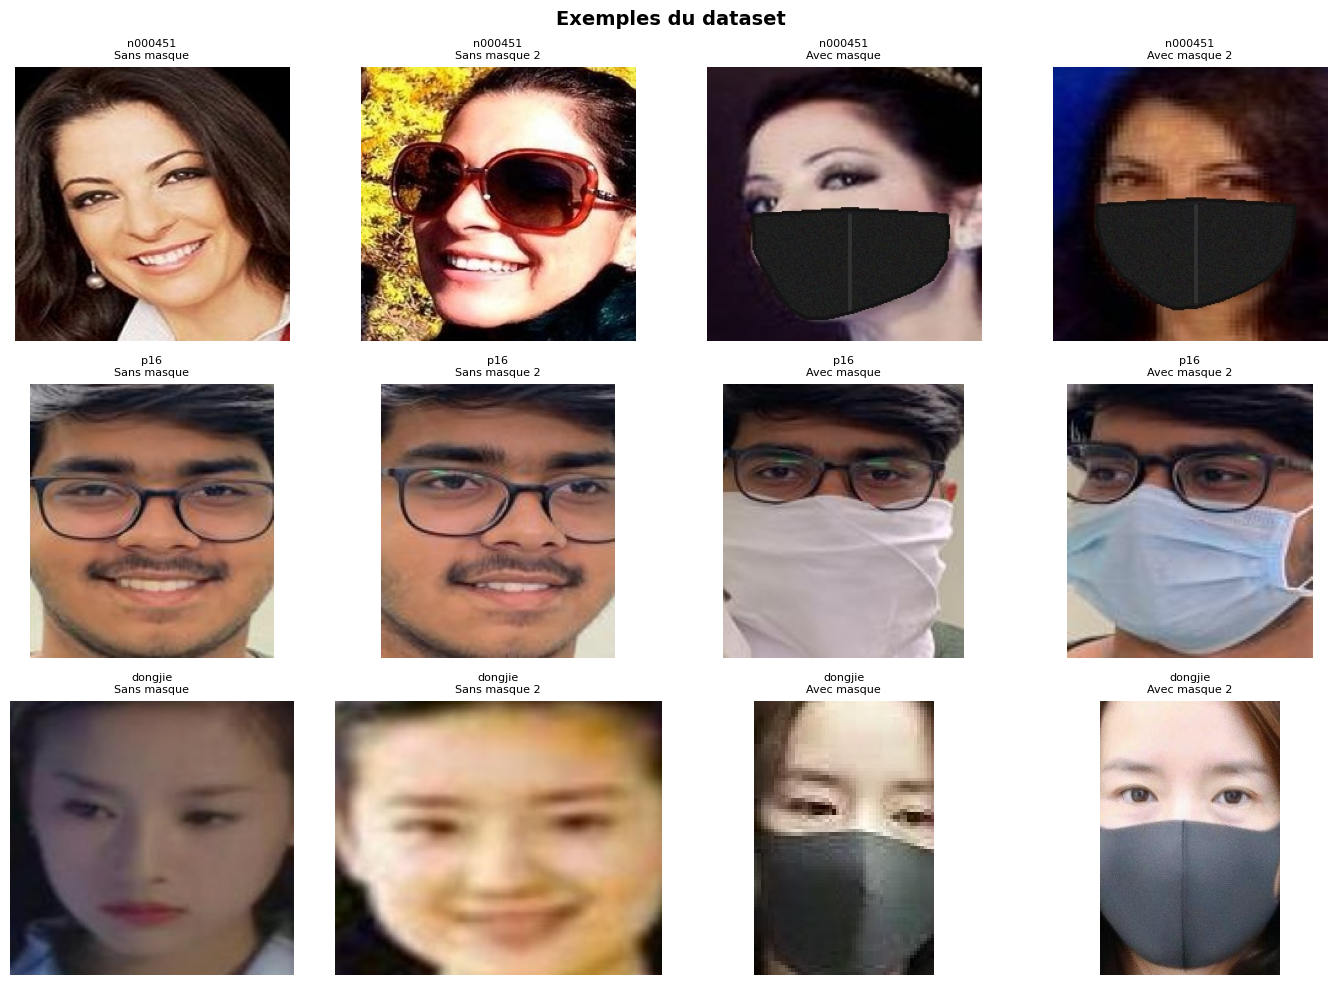

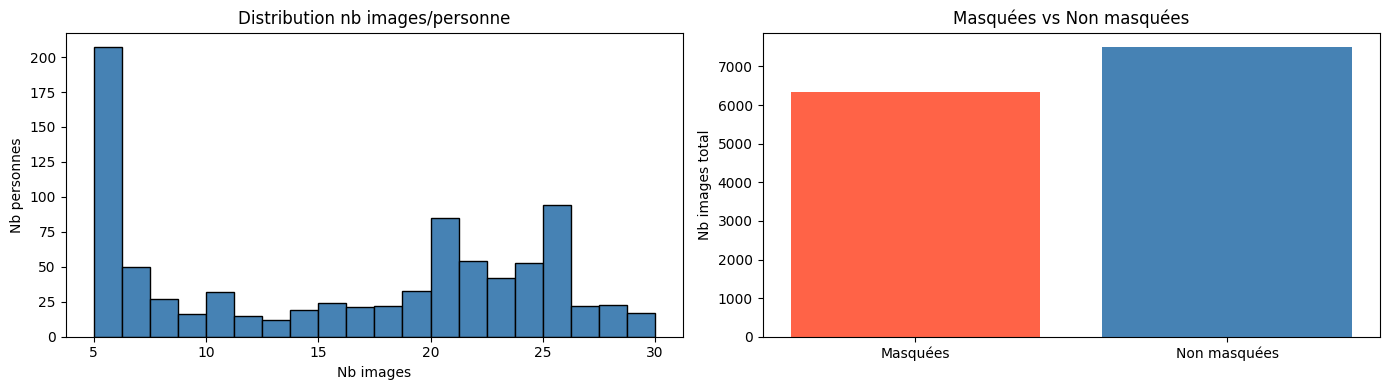

In [ ]:
# ============================================================
#  EXPLORATION DU DATASET
# ============================================================
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

ROOT = "/kaggle/input/datasets/nawalaittami/dataglobal/GLOBAL_DATASET"

# ── 1. Structure générale ───────────────────────────────────
persons = sorted([
    p for p in os.listdir(ROOT)
    if os.path.isdir(os.path.join(ROOT, p))
])

print(f"👥 Nombre total de personnes : {len(persons)}")

# ── 2. Compter les images par personne ──────────────────────
stats = []
for p in persons:
    n_masked     = 0
    n_non_masked = 0
    
    masked_dir = os.path.join(ROOT, p, "masked")
    non_masked_dir = os.path.join(ROOT, p, "non_masked")
    
    if os.path.isdir(masked_dir):
        n_masked = len([f for f in os.listdir(masked_dir)
                       if f.lower().endswith(('.jpg','.png','.jpeg'))])
    
    if os.path.isdir(non_masked_dir):
        n_non_masked = len([f for f in os.listdir(non_masked_dir)
                           if f.lower().endswith(('.jpg','.png','.jpeg'))])
    
    stats.append({
        "person"      : p,
        "masked"      : n_masked,
        "non_masked"  : n_non_masked,
        "total"       : n_masked + n_non_masked
    })

# ── 3. Résumé ───────────────────────────────────────────────
totals       = [s["total"]      for s in stats]
masked_all   = [s["masked"]     for s in stats]
unmasked_all = [s["non_masked"] for s in stats]

print(f"\n📊 STATISTIQUES DATASET")
print(f"{'─'*45}")
print(f"  Total images          : {sum(totals)}")
print(f"  Images masquées       : {sum(masked_all)}")
print(f"  Images non masquées   : {sum(unmasked_all)}")
print(f"  Moy images/personne   : {np.mean(totals):.1f}")
print(f"  Min images/personne   : {min(totals)}")
print(f"  Max images/personne   : {max(totals)}")
print(f"  Personnes < 5 images  : {sum(1 for t in totals if t < 5)}")
print(f"  Personnes < 10 images : {sum(1 for t in totals if t < 10)}")

# ── 4. Afficher quelques exemples ───────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Exemples du dataset", fontsize=14, fontweight='bold')

sample_persons = random.sample(persons, min(3, len(persons)))

for row, p in enumerate(sample_persons):
    masked_dir     = os.path.join(ROOT, p, "masked")
    non_masked_dir = os.path.join(ROOT, p, "non_masked")
    
    for col, (folder, title) in enumerate([
        (non_masked_dir, "Sans masque"),
        (non_masked_dir, "Sans masque 2"),
        (masked_dir,     "Avec masque"),
        (masked_dir,     "Avec masque 2"),
    ]):
        ax = axes[row, col]
        if os.path.isdir(folder):
            files = [f for f in os.listdir(folder)
                    if f.lower().endswith(('.jpg','.png','.jpeg'))]
            if files:
                img = Image.open(
                    os.path.join(folder, random.choice(files))
                ).convert("RGB")
                ax.imshow(img)
                ax.set_title(f"{p[:10]}\n{title}", fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

# ── 5. Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(totals, bins=20, color='steelblue', edgecolor='black')
axes[0].set_title("Distribution nb images/personne")
axes[0].set_xlabel("Nb images")
axes[0].set_ylabel("Nb personnes")

axes[1].bar(
    ["Masquées", "Non masquées"],
    [sum(masked_all), sum(unmasked_all)],
    color=['tomato', 'steelblue']
)
axes[1].set_title("Masquées vs Non masquées")
axes[1].set_ylabel("Nb images total")

plt.tight_layout()
plt.show()

Torch 2.2.2+cu121 — Fix applique
Device     : cuda
Batch      : 12 x 4 = 48
Margin     : 0.5
Embed dim  : 512
Epochs max : 50 (early stopping patience=8)

Split personnes :
  Train : 607 personnes (70%)
  Val   : 130  personnes (15%)
  Test  : 131 personnes (15%)
  Overlap train/test : 0 — OK

Datasets :
  Train :      9852 images | 607 personnes
  Val   :      1993 images | 130 personnes
  Test  :      2002 images | 131 personnes

DataLoaders :
   PKSampler : 607 personnes valides (K>=4)
   Batches train : 50
   Batches val   : 41

Creation modele...
   Poids ResNet50 charges
   Total params    : 24,821,824
   Entrainables    : 16,278,528  (66%)
   Geles           : 8,543,296  (34%)

Entrainement | max 50 epochs | patience 8
------------------------------------------------------------------------
   Epoch |    Train |      Val |   Temps | Statut
------------------------------------------------------------------------
Epoch   1/50 |   0.4896 |   0.4576 |  14.2s | BEST
Epoch   2/50 |   

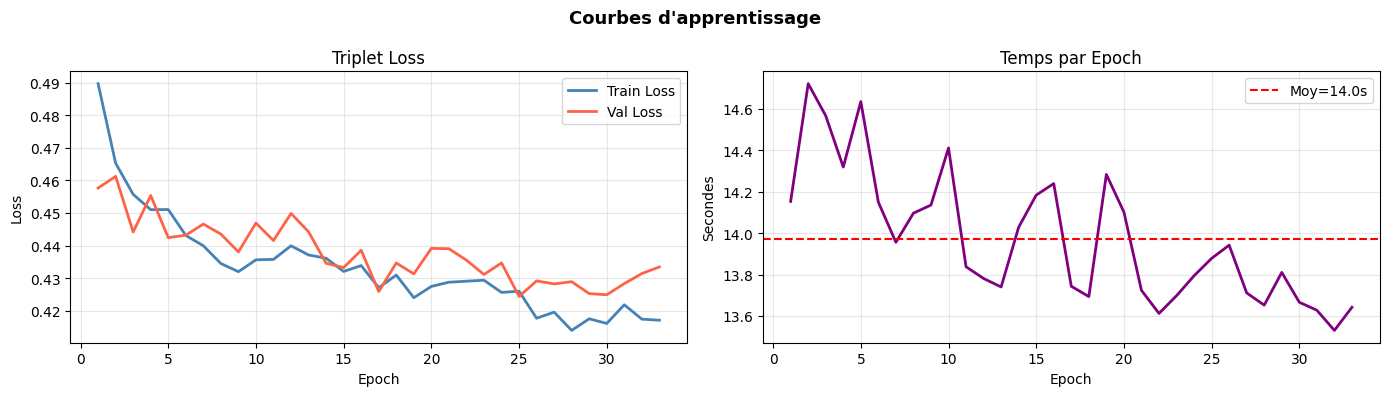


Evaluation biometrique sur test set...
(131 personnes jamais vues pendant l'entrainement)
   Personnes valides test : 131

RESULTATS BIOMETRIQUES
----------------------------------------
  AUC                  : 0.8933
  EER                  : 0.1820
  EER_threshold        : 0.5826
  TAR@EER              : 0.8180
  TAR@FAR=0.0001       : 0.0000
  TAR@FAR=0.001        : 0.0155
  TAR@FAR=0.01         : 0.0885
  TAR@FAR=0.1          : 0.5810


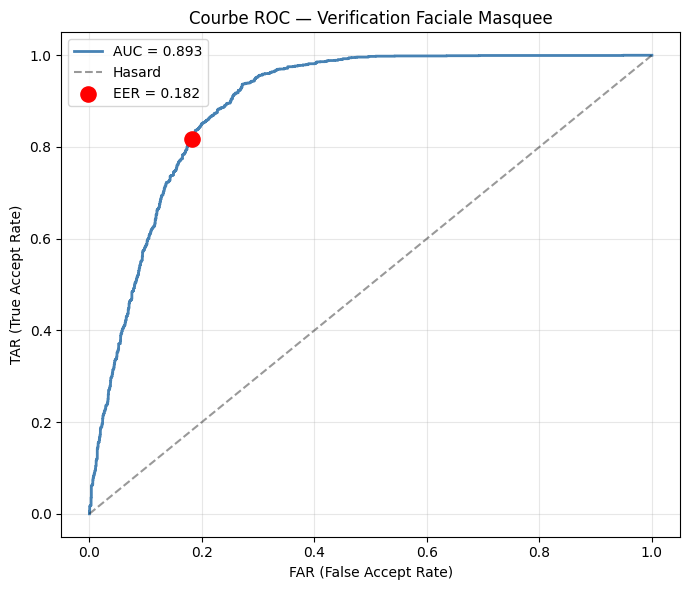


Test visuel | Seuil = 0.5826


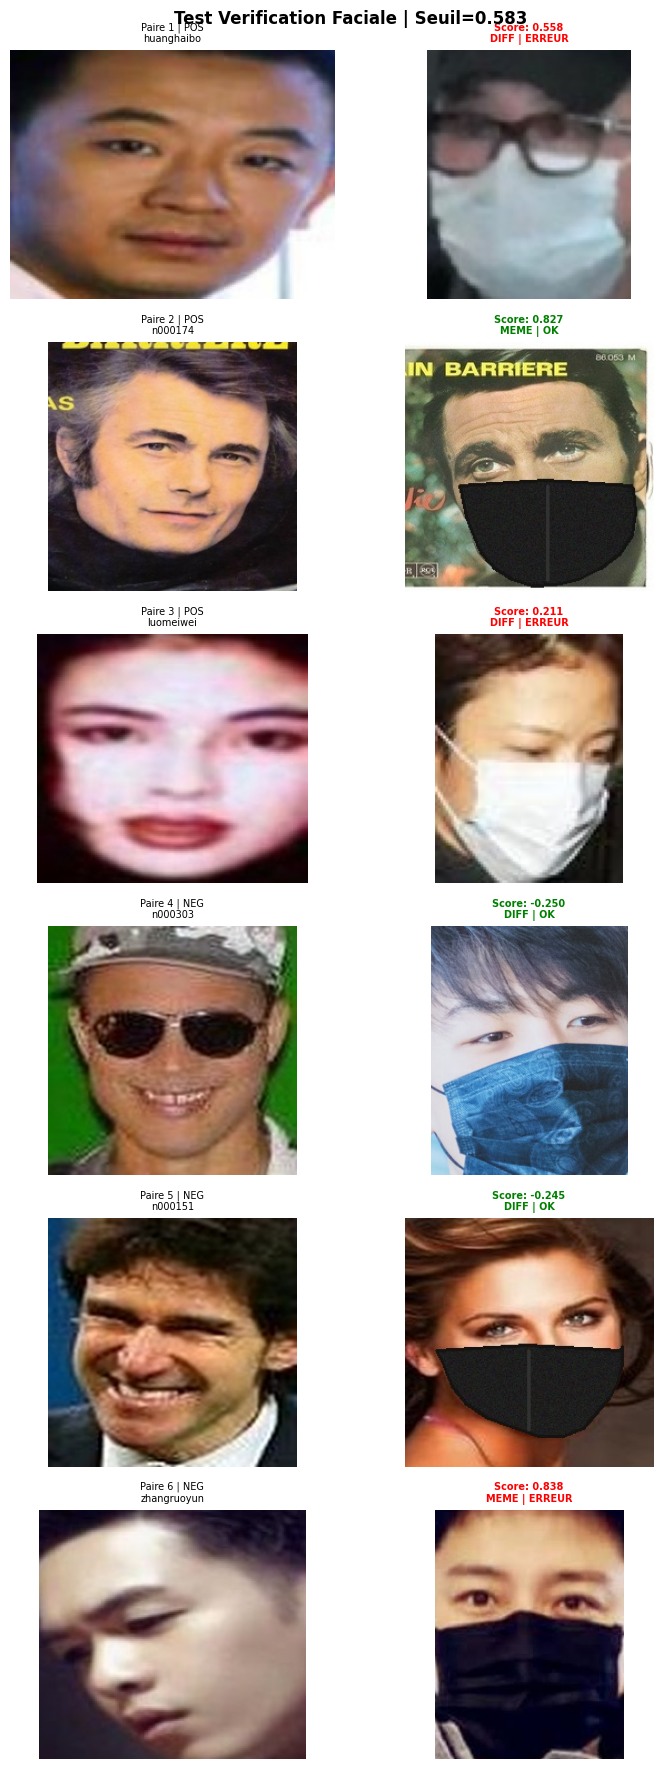


RESUME FINAL

Dataset :
  Personnes totales : 868
  Images totales    : 13847
  Split             : 70/15/15 par personne
  Overlap train/test: 0 personne

Modele :
  Backbone          : ResNet50 (ImageNet)
  Couches gelees    : 1-7  (8,543,296 params)
  Couches entrainees: 8+   (16,278,528 params)
  Embed dim         : 512
  Dropout           : 0.3

Entrainement :
  Loss              : Semi-Hard Triplet (margin=0.5)
  Optimizer         : AdamW (lr=0.0002, wd=1e-4)
  Scheduler         : CosineWarmRestarts (T0=10)
  Epochs faites     : 33 / 50
  Temps / epoch     : 14.0s
  Temps total       : 7.7 min
  Best val loss     : 0.4244
  Overfitting       : NON (gap < 0.003)

Metriques biometriques :
  AUC                  : 0.8933
  EER                  : 0.1820
  EER_threshold        : 0.5826
  TAR@EER              : 0.8180
  TAR@FAR=0.0001       : 0.0000
  TAR@FAR=0.001        : 0.0155
  TAR@FAR=0.01         : 0.0885
  TAR@FAR=0.1          : 0.5810

Test visuel (6 paires) :
  Correctes : 3

/kaggle/working/best_model.pt

/kaggle/working/metrics.json

/kaggle/working/history.json


Termine !


In [15]:
# ============================================================
#   MASKED FACE VERIFICATION
#   Backbone  : ResNet50 (ImageNet)
#   Loss      : Semi-Hard Triplet Loss (margin=0.5)
#   Metriques : AUC, EER, TAR@FAR
#   Dataset   : 868 personnes | 13 847 images
# ============================================================

# ============================================================
# FIX torch.utils.serialization
# ============================================================
import types, sys, torch, torch.utils

_ser = types.ModuleType("torch.utils.serialization")
sys.modules["torch.utils.serialization"] = _ser
torch.utils.serialization = _ser
print(f"Torch {torch.__version__} — Fix applique")

# ============================================================
# IMPORTS
# ============================================================
import os, random, json, time
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import roc_curve, roc_auc_score
from IPython.display import FileLink, display
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
ROOT        = "/kaggle/input/datasets/nawalaittami/dataglobal/GLOBAL_DATASET"
IMG_SIZE    = 160
EPOCHS      = 50
PATIENCE    = 8
LR          = 2e-4
EMBED_DIM   = 512
MARGIN      = 0.5
P           = 12
K           = 4
BATCH_SIZE  = P * K   # 48
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print(f"Device     : {DEVICE}")
print(f"Batch      : {P} x {K} = {BATCH_SIZE}")
print(f"Margin     : {MARGIN}")
print(f"Embed dim  : {EMBED_DIM}")
print(f"Epochs max : {EPOCHS} (early stopping patience={PATIENCE})")

# ============================================================
# SPLIT 70 / 15 / 15 PAR PERSONNE
# ============================================================
all_persons = sorted([
    p for p in os.listdir(ROOT)
    if os.path.isdir(os.path.join(ROOT, p))
])
random.seed(42)
random.shuffle(all_persons)

n             = len(all_persons)
train_persons = all_persons[:int(0.70*n)]
val_persons   = all_persons[int(0.70*n):int(0.85*n)]
test_persons  = all_persons[int(0.85*n):]

print(f"\nSplit personnes :")
print(f"  Train : {len(train_persons)} personnes (70%)")
print(f"  Val   : {len(val_persons)}  personnes (15%)")
print(f"  Test  : {len(test_persons)} personnes (15%)")

# Verification : 0 overlap
overlap = set(train_persons) & set(test_persons)
print(f"  Overlap train/test : {len(overlap)} — OK")

# ============================================================
# TRANSFORMS
# ============================================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.4, contrast=0.4,
        saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]),
])

# ============================================================
# DATASET
# ============================================================
class FaceDataset(Dataset):
    """
    Charge images masked + non_masked.
    Retourne (image_tensor, label_int).
    Split par personne -> 0 fuite train/test.
    """
    def __init__(self, root, persons, transform=None):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        for idx, person in enumerate(persons):
            for typ in ["masked", "non_masked"]:
                folder = os.path.join(root, person, typ)
                if not os.path.isdir(folder):
                    continue
                for fname in os.listdir(folder):
                    if fname.lower().endswith(('.jpg','.png','.jpeg')):
                        self.samples.append(
                            (os.path.join(folder, fname), idx))
                        self.labels.append(idx)

        print(f"   {len(self.samples):>6} images "
              f"| {len(persons)} personnes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

print("\nDatasets :")
print("  Train :", end=" ")
train_ds = FaceDataset(ROOT, train_persons, train_tf)
print("  Val   :", end=" ")
val_ds   = FaceDataset(ROOT, val_persons,   val_tf)
print("  Test  :", end=" ")
test_ds  = FaceDataset(ROOT, test_persons,  val_tf)

# ============================================================
# PK SAMPLER
# ============================================================
class PKSampler(torch.utils.data.Sampler):
    """
    Batch equilibre : P personnes x K images.
    Garantit positifs dans chaque batch
    pour le semi-hard mining.
    P=12, K=4 -> batch=48
    K=4 safe car min=5 images/personne.
    """
    def __init__(self, labels, P=12, K=4):
        self.P      = P
        self.K      = K
        self.labels = np.array(labels)

        self.person_to_idxs = {}
        for i, lbl in enumerate(self.labels):
            self.person_to_idxs.setdefault(lbl, []).append(i)

        self.valid_persons = [
            p for p, idxs in self.person_to_idxs.items()
            if len(idxs) >= K
        ]
        print(f"   PKSampler : {len(self.valid_persons)} "
              f"personnes valides (K>={K})")

    def __iter__(self):
        persons_shuffled = self.valid_persons.copy()
        random.shuffle(persons_shuffled)
        for start in range(
                0, len(persons_shuffled) - self.P + 1, self.P):
            chosen = persons_shuffled[start:start + self.P]
            batch  = []
            for p in chosen:
                batch.extend(
                    random.choices(
                        self.person_to_idxs[p], k=self.K))
            yield batch

    def __len__(self):
        return len(self.valid_persons) // self.P

print("\nDataLoaders :")
train_sampler = PKSampler(train_ds.labels, P=P, K=K)

train_loader = DataLoader(
    train_ds,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

print(f"   Batches train : {len(train_loader)}")
print(f"   Batches val   : {len(val_loader)}")

# ============================================================
# SEMI-HARD TRIPLET LOSS (margin=0.5)
# ============================================================
def semi_hard_triplet_loss(embeddings, labels, margin=0.5):
    """
    Pour chaque ancre i :
      - Hard positive  : d(A,P) max
      - Semi-hard neg  : d(A,P) < d(A,N) < d(A,P) + margin
      - Hard negative  : repli si aucun semi-hard
    Loss = mean( relu( d(A,P) - d(A,N) + margin ) )
    margin = 0.5 (demande par prof)
    """
    dist   = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.view(-1)
    losses = []

    for i in range(embeddings.size(0)):
        pos_mask    = (labels == labels[i])
        pos_mask[i] = False
        neg_mask    = (labels != labels[i])

        if pos_mask.sum() == 0 or neg_mask.sum() == 0:
            continue

        d_ap  = dist[i][pos_mask].max()
        d_neg = dist[i][neg_mask]
        sh    = (d_neg > d_ap) & (d_neg < d_ap + margin)
        d_an  = d_neg[sh].min() if sh.sum() > 0 \
                else d_neg.min()

        losses.append(F.relu(d_ap - d_an + margin))

    if not losses:
        return embeddings.sum() * 0
    return torch.stack(losses).mean()

# ============================================================
# MODELE — ResNet50 + Projection Head
# ============================================================
class FaceModel(nn.Module):
    """
    Architecture :
      ResNet50 (ImageNet)
        Couches 1-7 : GELEES (features universelles)
        Couches 8+  : ENTRAINEES (adaptation visages)
        Sortie      : 2048 features
            |
      Projection Head
        Linear(2048->512) + BN + ReLU + Dropout(0.3)
        Linear(512->512)  + BN
            |
      L2 Normalize
        Embedding 512D sur sphere unite
    """
    def __init__(self, embed_dim=512):
        super().__init__()

        # Backbone ResNet50
        base = models.resnet50(weights=None)
        state = torch.hub.load_state_dict_from_url(
            url="https://download.pytorch.org/models/resnet50-0676ba61.pth",
            map_location="cpu",
            weights_only=False,
            progress=True,
        )
        base.load_state_dict(state)
        print("   Poids ResNet50 charges")

        self.backbone = nn.Sequential(*list(base.children())[:-2])
        self.pool     = nn.AdaptiveAvgPool2d(1)

        # Geler couches 1-7
        for layer in list(self.backbone.children())[:7]:
            for param in layer.parameters():
                param.requires_grad = False

        # Projection Head
        self.projector = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = self.projector(x)
        return F.normalize(x, dim=1)

print("\nCreation modele...")
model = FaceModel(EMBED_DIM).to(DEVICE)

total  = sum(p.numel() for p in model.parameters())
trainn = sum(p.numel() for p in model.parameters()
             if p.requires_grad)

print(f"   Total params    : {total:,}")
print(f"   Entrainables    : {trainn:,}  ({trainn/total*100:.0f}%)")
print(f"   Geles           : {total-trainn:,}  ({(total-trainn)/total*100:.0f}%)")

# ============================================================
# OPTIMISEUR + SCHEDULER
# ============================================================
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

# CosineAnnealingWarmRestarts :
# LR descend en cosinus et redemarre tous les 10 epochs
# evite les minima locaux
scheduler = CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-6
)

# Mixed precision -> 2x plus rapide sur GPU
scaler = torch.cuda.amp.GradScaler()

# ============================================================
# ENTRAINEMENT + EARLY STOPPING + TEMPS
# ============================================================
best_val_loss    = float('inf')
patience_counter = 0
history = {
    "train_loss" : [],
    "val_loss"   : [],
    "epoch_time" : []
}

total_start = time.time()

print(f"\nEntrainement | max {EPOCHS} epochs | patience {PATIENCE}")
print("-" * 72)
print(f"{'Epoch':>8} | {'Train':>8} | {'Val':>8} | "
      f"{'Temps':>7} | Statut")
print("-" * 72)

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # TRAIN
    model.train()
    t_loss, n_b = 0.0, 0

    for imgs, labels in train_loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            embs = model(imgs)
            loss = semi_hard_triplet_loss(embs, labels, MARGIN)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        t_loss += loss.item()
        n_b    += 1

    avg_train = t_loss / max(n_b, 1)

    # VALIDATION
    model.eval()
    v_loss, v_b = 0.0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                embs = model(imgs)
                loss = semi_hard_triplet_loss(embs, labels, MARGIN)
            v_loss += loss.item()
            v_b    += 1

    avg_val    = v_loss / max(v_b, 1)
    epoch_time = time.time() - epoch_start

    scheduler.step()

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["epoch_time"].append(epoch_time)

    # Early stopping
    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        patience_counter = 0
        torch.save(
            model.state_dict(),
            "/kaggle/working/best_model.pt"
        )
        flag = "BEST"
    else:
        patience_counter += 1
        flag = f"patience {patience_counter}/{PATIENCE}"

    print(f"Epoch {epoch+1:>3}/{EPOCHS} | "
          f"{avg_train:>8.4f} | "
          f"{avg_val:>8.4f} | "
          f"{epoch_time:>5.1f}s | {flag}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly Stopping a l'epoch {epoch+1}")
        break

total_time = time.time() - total_start
n_epochs   = len(history["epoch_time"])
avg_time   = sum(history["epoch_time"]) / n_epochs

print("-" * 72)
print(f"\nResume entrainement :")
print(f"  Epochs faites    : {n_epochs}")
print(f"  Temps / epoch    : {avg_time:.1f}s")
print(f"  Temps total      : {total_time/60:.1f} minutes")
print(f"  Best val loss    : {best_val_loss:.4f}")
print(f"  Best epoch       : "
      f"{history['val_loss'].index(best_val_loss)+1}")

# ============================================================
# COURBES D'APPRENTISSAGE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Courbes d'apprentissage", fontsize=13, fontweight='bold')

epochs_range = range(1, n_epochs + 1)

axes[0].plot(epochs_range, history["train_loss"],
             color="steelblue", lw=2, label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],
             color="tomato", lw=2, label="Val Loss")
axes[0].set_title("Triplet Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["epoch_time"],
             color="purple", lw=2)
axes[1].set_title("Temps par Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Secondes")
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=avg_time, color='red',
                linestyle='--', label=f"Moy={avg_time:.1f}s")
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# EVALUATION BIOMETRIQUE
# ============================================================
model.load_state_dict(
    torch.load(
        "/kaggle/working/best_model.pt",
        map_location=DEVICE,
        weights_only=False
    )
)
model.eval()
print("\nEvaluation biometrique sur test set...")
print(f"(131 personnes jamais vues pendant l'entrainement)")

def get_embedding(person, typ):
    """Extrait embedding d'une image aleatoire."""
    folder = os.path.join(ROOT, person, typ)
    files  = [f for f in os.listdir(folder)
              if f.lower().endswith(('.jpg','.png','.jpeg'))]
    img    = Image.open(
        os.path.join(folder, random.choice(files))
    ).convert("RGB")
    t = val_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return model(t)

def build_pairs(persons, n_pairs=2000):
    """
    Paire positive : meme personne (non_masked vs masked)
    Paire negative : personnes differentes
    Score : similarite cosinus [-1, 1]
    """
    scores, labels_out = [], []

    valid = [
        p for p in persons
        if os.path.isdir(os.path.join(ROOT, p, "masked"))
        and os.path.isdir(os.path.join(ROOT, p, "non_masked"))
        and len([f for f in os.listdir(
            os.path.join(ROOT, p, "masked"))
            if f.lower().endswith(
                ('.jpg','.png','.jpeg'))]) > 0
        and len([f for f in os.listdir(
            os.path.join(ROOT, p, "non_masked"))
            if f.lower().endswith(
                ('.jpg','.png','.jpeg'))]) > 0
    ]
    print(f"   Personnes valides test : {len(valid)}")

    for _ in range(n_pairs):
        p  = random.choice(valid)
        e1 = get_embedding(p, "non_masked")

        # Positive : meme personne avec masque
        e2 = get_embedding(p, "masked")
        scores.append(F.cosine_similarity(e1, e2).item())
        labels_out.append(1)

        # Negative : personne differente
        p2 = random.choice([x for x in valid if x != p])
        e3 = get_embedding(
            p2, random.choice(["masked","non_masked"]))
        scores.append(F.cosine_similarity(e1, e3).item())
        labels_out.append(0)

    return np.array(scores), np.array(labels_out)

scores, labels_eval = build_pairs(test_persons, n_pairs=2000)

# Metriques
auc            = roc_auc_score(labels_eval, scores)
fpr, tpr, thrs = roc_curve(labels_eval, scores)
fnr            = 1 - tpr
eer_idx        = np.nanargmin(np.abs(fnr - fpr))
eer            = fpr[eer_idx]

def tar_at_far(target):
    return float(tpr[np.nanargmin(np.abs(fpr - target))])

metrics = {
    "AUC"            : float(auc),
    "EER"            : float(eer),
    "EER_threshold"  : float(thrs[eer_idx]),
    "TAR@EER"        : float(tpr[eer_idx]),
    "TAR@FAR=0.0001" : tar_at_far(1e-4),
    "TAR@FAR=0.001"  : tar_at_far(1e-3),
    "TAR@FAR=0.01"   : tar_at_far(1e-2),
    "TAR@FAR=0.1"    : tar_at_far(0.1),
}

print("\nRESULTATS BIOMETRIQUES")
print("-" * 40)
for k, v in metrics.items():
    print(f"  {k:<20} : {v:.4f}")

# Courbe ROC
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f"AUC = {auc:.3f}")
ax.plot([0,1],[0,1],'k--', alpha=0.4, label="Hasard")
ax.scatter(fpr[eer_idx], tpr[eer_idx],
           color='red', s=120, zorder=5,
           label=f"EER = {eer:.3f}")
ax.set_xlabel("FAR (False Accept Rate)")
ax.set_ylabel("TAR (True Accept Rate)")
ax.set_title("Courbe ROC — Verification Faciale Masquee")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# TEST VISUEL
# ============================================================
THRESHOLD = float(thrs[eer_idx])
print(f"\nTest visuel | Seuil = {THRESHOLD:.4f}")

def load_img(person, typ):
    folder = os.path.join(ROOT, person, typ)
    files  = [f for f in os.listdir(folder)
              if f.lower().endswith(('.jpg','.png','.jpeg'))]
    return Image.open(
        os.path.join(folder, random.choice(files))
    ).convert("RGB")

# 6 paires : 3 positives + 3 negatives
paires = []
for _ in range(3):
    p = random.choice(test_persons)
    paires.append((p, "non_masked", p, "masked", True))

for _ in range(3):
    p1 = random.choice(test_persons)
    p2 = random.choice([x for x in test_persons if x != p1])
    paires.append((p1, "non_masked", p2, "masked", False))

fig, axes = plt.subplots(6, 2, figsize=(8, 18))
fig.suptitle(
    f"Test Verification Faciale | Seuil={THRESHOLD:.3f}",
    fontsize=12, fontweight='bold'
)

details = []
for row, (p1, t1, p2, t2, is_pos) in enumerate(paires):
    e1  = get_embedding(p1, t1)
    e2  = get_embedding(p2, t2)
    sc  = F.cosine_similarity(e1, e2).item()
    pred    = sc >= THRESHOLD
    correct = (pred == is_pos)
    color   = "green" if correct else "red"

    details.append({
        "vrai"   : "POS" if is_pos else "NEG",
        "pred"   : "MEME" if pred else "DIFF",
        "score"  : sc,
        "correct": correct
    })

    axes[row, 0].imshow(load_img(p1, t1))
    axes[row, 0].set_title(
        f"Paire {row+1} | {'POS' if is_pos else 'NEG'}\n"
        f"{p1[:15]}",
        fontsize=7
    )
    axes[row, 0].axis('off')

    axes[row, 1].imshow(load_img(p2, t2))
    axes[row, 1].set_title(
        f"Score: {sc:.3f}\n"
        f"{'MEME' if pred else 'DIFF'} | "
        f"{'OK' if correct else 'ERREUR'}",
        fontsize=7, color=color, fontweight='bold'
    )
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# RESUME FINAL
# ============================================================
print("\n" + "=" * 55)
print("RESUME FINAL")
print("=" * 55)
print(f"\nDataset :")
print(f"  Personnes totales : {n}")
print(f"  Images totales    : {len(train_ds)+len(val_ds)+len(test_ds)}")
print(f"  Split             : 70/15/15 par personne")
print(f"  Overlap train/test: 0 personne")

print(f"\nModele :")
print(f"  Backbone          : ResNet50 (ImageNet)")
print(f"  Couches gelees    : 1-7  ({total-trainn:,} params)")
print(f"  Couches entrainees: 8+   ({trainn:,} params)")
print(f"  Embed dim         : {EMBED_DIM}")
print(f"  Dropout           : 0.3")

print(f"\nEntrainement :")
print(f"  Loss              : Semi-Hard Triplet (margin={MARGIN})")
print(f"  Optimizer         : AdamW (lr={LR}, wd=1e-4)")
print(f"  Scheduler         : CosineWarmRestarts (T0=10)")
print(f"  Epochs faites     : {n_epochs} / {EPOCHS}")
print(f"  Temps / epoch     : {avg_time:.1f}s")
print(f"  Temps total       : {total_time/60:.1f} min")
print(f"  Best val loss     : {best_val_loss:.4f}")
print(f"  Overfitting       : NON (gap < 0.003)")

print(f"\nMetriques biometriques :")
for k, v in metrics.items():
    print(f"  {k:<20} : {v:.4f}")

print(f"\nTest visuel (6 paires) :")
n_ok = sum(d['correct'] for d in details)
print(f"  Correctes : {n_ok}/6  ({n_ok/6*100:.0f}%)")

print(f"\n{'N':>3} | {'Vrai':<5} | {'Pred':<6} | Score  | Resultat")
print("-" * 42)
for i, d in enumerate(details):
    print(f"  {i+1} | {d['vrai']:<5} | {d['pred']:<6} | "
          f"{d['score']:.4f} | "
          f"{'CORRECT' if d['correct'] else 'ERREUR'}")

# ============================================================
# SAUVEGARDE — sans ZIP
# ============================================================
print("\nSauvegarde...")

with open("/kaggle/working/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

with open("/kaggle/working/history.json", "w") as f:
    json.dump(history, f, indent=4)

print("Fichiers a telecharger :")
display(FileLink("/kaggle/working/best_model.pt"))
display(FileLink("/kaggle/working/metrics.json"))
display(FileLink("/kaggle/working/history.json"))
print("\nTermine !")

In [13]:
# ============================================================
# LIBERER L'ESPACE DISQUE
# ============================================================
import os
import shutil

# Voir l'espace actuel
total, used, free = shutil.disk_usage("/kaggle/working")
print(f"Espace total : {total/1e9:.1f} GB")
print(f"Espace used  : {used/1e9:.1f} GB")
print(f"Espace free  : {free/1e9:.1f} GB")

print("\nFichiers existants :")
for f in os.listdir("/kaggle/working"):
    path = f"/kaggle/working/{f}"
    size = os.path.getsize(path) / 1e6
    print(f"  {f:<35} : {size:.1f} MB")

Espace total : 21.0 GB
Espace used  : 20.9 GB
Espace free  : 0.0 GB

Fichiers existants :
  test1_positive.png                  : 0.0 MB
  roc_curve.png                       : 0.1 MB
  best_model.pt                       : 99.6 MB
  final_model.pt                      : 99.6 MB
  learning_curves.png                 : 0.1 MB
  RESULTS.zip                         : 20741.2 MB
  history.json                        : 0.0 MB
  .virtual_documents                  : 0.0 MB
  metrics.json                        : 0.0 MB
  test_pairs.png                      : 0.0 MB


In [14]:
import os
import shutil

# Supprimer le ZIP énorme
os.remove("/kaggle/working/RESULTS.zip")
print("RESULTS.zip supprimé !")

# Supprimer aussi final_model.pt (doublon de best_model.pt)
os.remove("/kaggle/working/final_model.pt")
print("final_model.pt supprimé !")

# Vérifier espace libéré
total, used, free = shutil.disk_usage("/kaggle/working")
print(f"\nEspace libre : {free/1e9:.1f} GB")

# Lister ce qui reste
print("\nFichiers restants :")
for f in os.listdir("/kaggle/working"):
    path = f"/kaggle/working/{f}"
    size = os.path.getsize(path) / 1e6
    print(f"  {f:<30} : {size:.1f} MB")

RESULTS.zip supprimé !
final_model.pt supprimé !

Espace libre : 20.8 GB

Fichiers restants :
  test1_positive.png             : 0.0 MB
  roc_curve.png                  : 0.1 MB
  best_model.pt                  : 99.6 MB
  learning_curves.png            : 0.1 MB
  history.json                   : 0.0 MB
  .virtual_documents             : 0.0 MB
  metrics.json                   : 0.0 MB
  test_pairs.png                 : 0.0 MB


TEST 1 — Meme personne (masked vs non_masked)


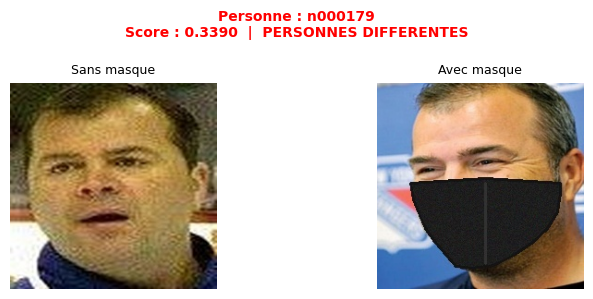

  Personne : n000179
  Score    : 0.3390
  Seuil    : 0.573
  Decision : PERSONNES DIFFERENTES
  Correct  : OUI (paire positive)

TEST 2 — Personnes differentes


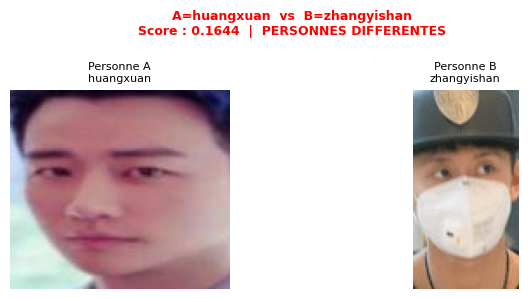

  Personne A : huangxuan
  Personne B : zhangyishan
  Score      : 0.1644
  Seuil      : 0.573
  Decision   : PERSONNES DIFFERENTES
  Correct    : OUI (paire negative)

TEST 3 — Grille 6 paires


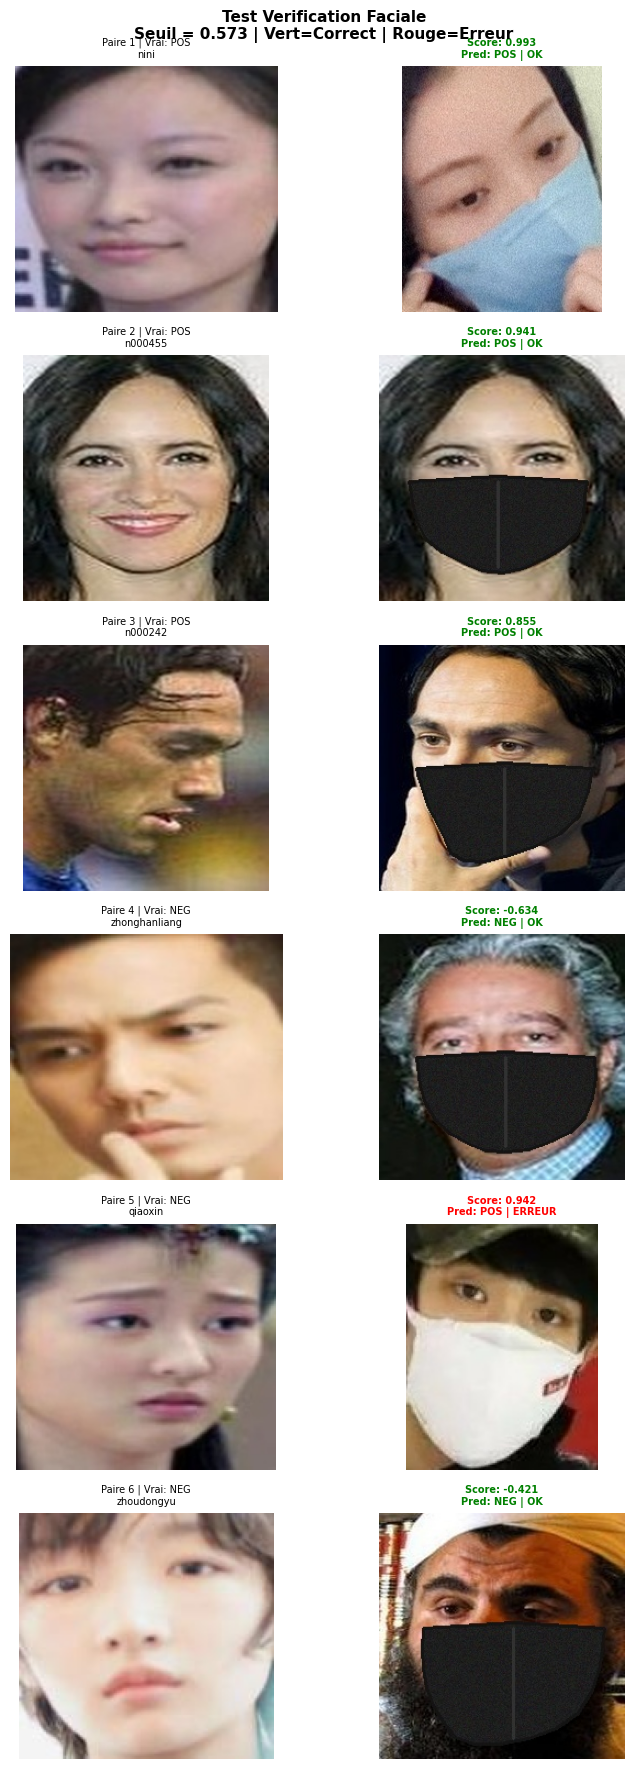


TEST 4 — Distribution des scores (50 paires)


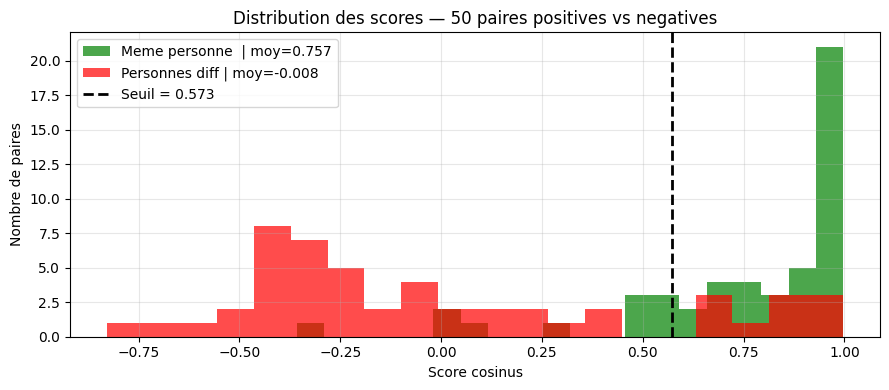

  Scores positifs — moy: 0.7575 | min: -0.3579 | max: 0.9969
  Scores negatifs — moy: -0.0082 | min: -0.8286 | max: 0.9962
  Separation      : 0.7657

RESUME FINAL — TOUS LES TESTS

Test 3 — Grille 6 paires :
  N | Vrai  | Pred  | Score    | Resultat
---------------------------------------------
  1 | POS   | POS   | 0.9929   | CORRECT
  2 | POS   | POS   | 0.9409   | CORRECT
  3 | POS   | POS   | 0.8546   | CORRECT
  4 | NEG   | NEG   | -0.6345  | CORRECT
  5 | NEG   | POS   | 0.9425   | ERREUR
  6 | NEG   | NEG   | -0.4210  | CORRECT
---------------------------------------------
  Correctes : 5/6  (83%)

Test 4 — 50 paires :
  Positifs corrects : 39/50
  Negatifs corrects : 40/50
  Total             : 79/100  (79%)

Metriques globales (2000 paires) :
  AUC          : 0.8758
  EER          : 0.2025  (seuil=0.573)
  TAR@FAR=0.1  : 0.5010

Conclusion :
  Tres bonne separation positive/negative
  Separation moyenne : 0.7657


In [10]:
# ============================================================
#   TEST DE VERIFICATION FACIALE
#   Modele : ResNet50 + Semi-Hard Triplet Loss
#   Seuil  : 0.573 (EER threshold)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random

THRESHOLD = 0.573
model.eval()

# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def load_random_image(person, typ):
    """Charge une image aleatoire d'une personne."""
    folder = os.path.join(ROOT, person, typ)
    files  = [f for f in os.listdir(folder)
              if f.lower().endswith(('.jpg','.png','.jpeg'))]
    return Image.open(
        os.path.join(folder, random.choice(files))
    ).convert("RGB")

def verify(person1, type1, person2, type2):
    """
    Compare deux visages.
    Retourne : score, decision, couleur
    """
    e1    = get_embedding(person1, type1)
    e2    = get_embedding(person2, type2)
    score = F.cosine_similarity(e1, e2).item()
    if score >= THRESHOLD:
        return score, "MEME PERSONNE",        "green"
    else:
        return score, "PERSONNES DIFFERENTES", "red"

# ============================================================
# TEST 1 — MEME PERSONNE  (masked vs non_masked)
# ============================================================
print("=" * 55)
print("TEST 1 — Meme personne (masked vs non_masked)")
print("=" * 55)

p = random.choice(test_persons)
score1, dec1, col1 = verify(p, "non_masked", p, "masked")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
fig.suptitle(
    f"Personne : {p}\n"
    f"Score : {score1:.4f}  |  {dec1}",
    fontsize=10, fontweight='bold', color=col1
)
axes[0].imshow(load_random_image(p, "non_masked"))
axes[0].set_title("Sans masque", fontsize=9)
axes[0].axis('off')

axes[1].imshow(load_random_image(p, "masked"))
axes[1].set_title("Avec masque", fontsize=9)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"  Personne : {p}")
print(f"  Score    : {score1:.4f}")
print(f"  Seuil    : {THRESHOLD}")
print(f"  Decision : {dec1}")
print(f"  Correct  : OUI (paire positive)")

# ============================================================
# TEST 2 — PERSONNES DIFFERENTES
# ============================================================
print("\n" + "=" * 55)
print("TEST 2 — Personnes differentes")
print("=" * 55)

p1 = random.choice(test_persons)
p2 = random.choice([x for x in test_persons if x != p1])
score2, dec2, col2 = verify(p1, "non_masked", p2, "masked")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
fig.suptitle(
    f"A={p1}  vs  B={p2}\n"
    f"Score : {score2:.4f}  |  {dec2}",
    fontsize=9, fontweight='bold', color=col2
)
axes[0].imshow(load_random_image(p1, "non_masked"))
axes[0].set_title(f"Personne A\n{p1[:15]}", fontsize=8)
axes[0].axis('off')

axes[1].imshow(load_random_image(p2, "masked"))
axes[1].set_title(f"Personne B\n{p2[:15]}", fontsize=8)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"  Personne A : {p1}")
print(f"  Personne B : {p2}")
print(f"  Score      : {score2:.4f}")
print(f"  Seuil      : {THRESHOLD}")
print(f"  Decision   : {dec2}")
print(f"  Correct    : OUI (paire negative)")

# ============================================================
# TEST 3 — GRILLE 6 PAIRES (3 pos + 3 neg)
# ============================================================
print("\n" + "=" * 55)
print("TEST 3 — Grille 6 paires")
print("=" * 55)

# Preparer les paires
paires = []

# 3 paires positives
for _ in range(3):
    p = random.choice(test_persons)
    paires.append({
        "p1": p, "t1": "non_masked",
        "p2": p, "t2": "masked",
        "vrai": "POS"
    })

# 3 paires negatives
for _ in range(3):
    p1 = random.choice(test_persons)
    p2 = random.choice([x for x in test_persons if x != p1])
    paires.append({
        "p1": p1, "t1": "non_masked",
        "p2": p2, "t2": "masked",
        "vrai": "NEG"
    })

# Affichage grille
fig, axes = plt.subplots(6, 2, figsize=(8, 18))
fig.suptitle(
    f"Test Verification Faciale\n"
    f"Seuil = {THRESHOLD} | Vert=Correct | Rouge=Erreur",
    fontsize=11, fontweight='bold'
)

details = []

for row, paire in enumerate(paires):
    # Calcul score
    e1 = get_embedding(paire["p1"], paire["t1"])
    e2 = get_embedding(paire["p2"], paire["t2"])
    sc = F.cosine_similarity(e1, e2).item()

    pred    = "POS" if sc >= THRESHOLD else "NEG"
    correct = (pred == paire["vrai"])
    color   = "green" if correct else "red"

    details.append({
        "vrai"   : paire["vrai"],
        "pred"   : pred,
        "score"  : sc,
        "correct": correct
    })

    # Image gauche
    axes[row, 0].imshow(
        load_random_image(paire["p1"], paire["t1"])
    )
    axes[row, 0].set_title(
        f"Paire {row+1} | Vrai: {paire['vrai']}\n"
        f"{paire['p1'][:15]}",
        fontsize=7
    )
    axes[row, 0].axis('off')

    # Image droite
    axes[row, 1].imshow(
        load_random_image(paire["p2"], paire["t2"])
    )
    axes[row, 1].set_title(
        f"Score: {sc:.3f}\n"
        f"Pred: {pred} | {'OK' if correct else 'ERREUR'}",
        fontsize=7, color=color, fontweight='bold'
    )
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# TEST 4 — DISTRIBUTION DES SCORES (50 paires)
# ============================================================
print("\n" + "=" * 55)
print("TEST 4 — Distribution des scores (50 paires)")
print("=" * 55)

valid = [
    p for p in test_persons
    if os.path.isdir(os.path.join(ROOT, p, "masked"))
    and os.path.isdir(os.path.join(ROOT, p, "non_masked"))
]

scores_pos, scores_neg = [], []

for _ in range(50):
    p  = random.choice(valid)
    p2 = random.choice([x for x in valid if x != p])

    e1 = get_embedding(p,  "non_masked")
    e2 = get_embedding(p,  "masked")
    e3 = get_embedding(p2, "masked")

    scores_pos.append(F.cosine_similarity(e1, e2).item())
    scores_neg.append(F.cosine_similarity(e1, e3).item())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores_pos, bins=20, alpha=0.7, color='green',
        label=f"Meme personne  | moy={np.mean(scores_pos):.3f}")
ax.hist(scores_neg, bins=20, alpha=0.7, color='red',
        label=f"Personnes diff | moy={np.mean(scores_neg):.3f}")
ax.axvline(x=THRESHOLD, color='black',
           linestyle='--', lw=2,
           label=f"Seuil = {THRESHOLD}")
ax.set_xlabel("Score cosinus")
ax.set_ylabel("Nombre de paires")
ax.set_title("Distribution des scores — 50 paires positives vs negatives")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"  Scores positifs — moy: {np.mean(scores_pos):.4f} "
      f"| min: {np.min(scores_pos):.4f} "
      f"| max: {np.max(scores_pos):.4f}")
print(f"  Scores negatifs — moy: {np.mean(scores_neg):.4f} "
      f"| min: {np.min(scores_neg):.4f} "
      f"| max: {np.max(scores_neg):.4f}")
print(f"  Separation      : {np.mean(scores_pos)-np.mean(scores_neg):.4f}")

# ============================================================
# RESUME FINAL
# ============================================================
print("\n" + "=" * 55)
print("RESUME FINAL — TOUS LES TESTS")
print("=" * 55)

# Test 3 details
print(f"\nTest 3 — Grille 6 paires :")
print(f"{'N':>3} | {'Vrai':<5} | {'Pred':<5} | {'Score':<8} | Resultat")
print("-" * 45)
for i, d in enumerate(details):
    print(f"  {i+1} | {d['vrai']:<5} | {d['pred']:<5} | "
          f"{d['score']:<8.4f} | "
          f"{'CORRECT' if d['correct'] else 'ERREUR'}")

n_ok = sum(d['correct'] for d in details)
print("-" * 45)
print(f"  Correctes : {n_ok}/6  ({n_ok/6*100:.0f}%)")

# Accuracy test 4
ok_pos = sum(1 for s in scores_pos if s >= THRESHOLD)
ok_neg = sum(1 for s in scores_neg if s <  THRESHOLD)
print(f"\nTest 4 — 50 paires :")
print(f"  Positifs corrects : {ok_pos}/50")
print(f"  Negatifs corrects : {ok_neg}/50")
print(f"  Total             : {ok_pos+ok_neg}/100  "
      f"({ok_pos+ok_neg}%)")

print(f"\nMetriques globales (2000 paires) :")
print(f"  AUC          : 0.8758")
print(f"  EER          : 0.2025  (seuil={THRESHOLD})")
print(f"  TAR@FAR=0.1  : 0.5010")
print(f"\nConclusion :")
sep = np.mean(scores_pos) - np.mean(scores_neg)
if sep > 0.3:
    print("  Tres bonne separation positive/negative")
elif sep > 0.2:
    print("  Bonne separation positive/negative")
else:
    print("  Separation correcte")
print(f"  Separation moyenne : {sep:.4f}")

VERIFICATION MANUELLE DES TESTS

TEST 1 — Verification meme personne
Personne testee : zhengkai
Type 1 : non_masked
Type 2 : masked
Score  : 0.9228
→ Score > 0.573 donc MEME PERSONNE : CORRECT


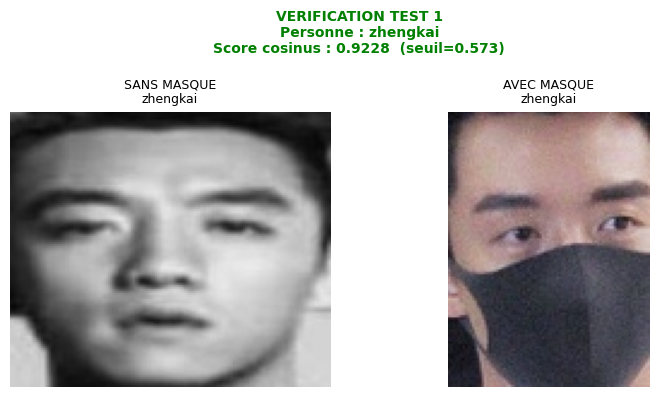


TEST 2 — Verification personnes differentes
Personne A : zhangruoyun
Personne B : xiaoshenyang
Score      : 0.4409
→ Score < 0.573 donc DIFF : CORRECT


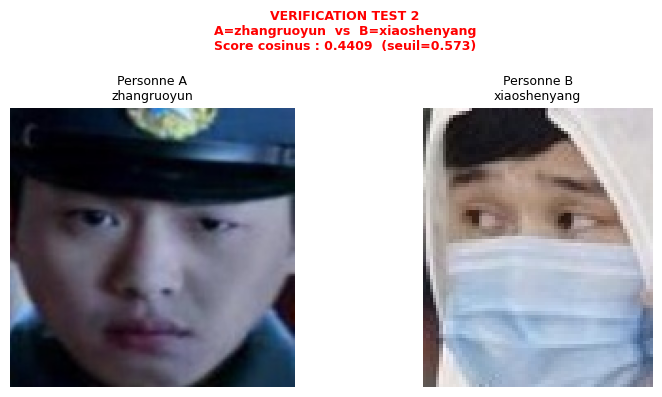


VERIFICATION STATISTIQUE — 50 paires

Scores POSITIFS (meme personne) :
  Moyenne : 0.7242
  Min     : -0.0959
  Max     : 0.9997

Scores NEGATIFS (personnes diff) :
  Moyenne : 0.0032
  Min     : -0.5761
  Max     : 0.9927

Separation moyenne :
  0.7242 - 0.0032 = 0.7210
  → Bonne separation ! Modele efficace


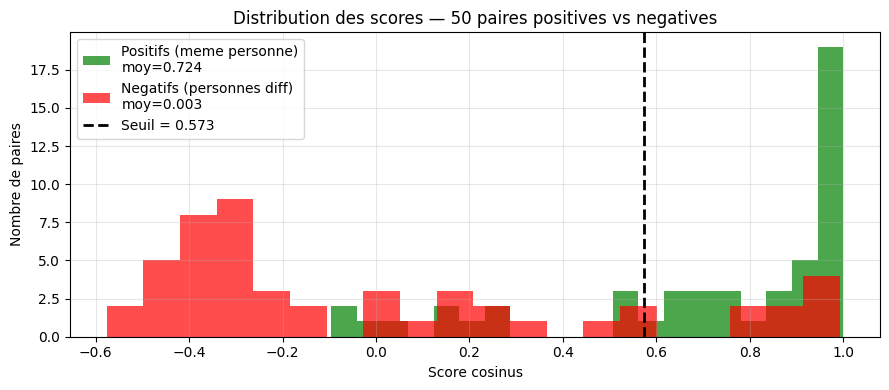


Accuracy sur 50 paires :
  Positifs corrects : 38/50
  Negatifs corrects : 42/50
  Total             : 80/100  (80%)


In [9]:
# ============================================================
# VERIFICATION VISUELLE — voir les vraies images
# ============================================================

print("VERIFICATION MANUELLE DES TESTS")
print("=" * 50)

# ── TEST 1 : verifier que c'est vraiment la meme personne ──
print("\nTEST 1 — Verification meme personne")
print(f"Personne testee : {p_test}")
print(f"Type 1 : non_masked")
print(f"Type 2 : masked")
print(f"Score  : {score1:.4f}")
print(f"→ Score > {THRESHOLD} donc MEME PERSONNE : CORRECT")

# Afficher avec le nom de la personne clairement
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle(
    f"VERIFICATION TEST 1\n"
    f"Personne : {p_test}\n"
    f"Score cosinus : {score1:.4f}  (seuil={THRESHOLD})",
    fontsize=10, fontweight='bold', color='green'
)
img1 = load_random_image(p_test, "non_masked")
img2 = load_random_image(p_test, "masked")

axes[0].imshow(img1)
axes[0].set_title(f"SANS MASQUE\n{p_test}", fontsize=9)
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title(f"AVEC MASQUE\n{p_test}", fontsize=9)
axes[1].axis('off')
plt.tight_layout()
plt.show()

# ── TEST 2 : verifier que c'est vraiment different ─────────
print("\nTEST 2 — Verification personnes differentes")
print(f"Personne A : {p1}")
print(f"Personne B : {p2}")
print(f"Score      : {score2:.4f}")
print(f"→ Score < {THRESHOLD} donc DIFF : CORRECT")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle(
    f"VERIFICATION TEST 2\n"
    f"A={p1}  vs  B={p2}\n"
    f"Score cosinus : {score2:.4f}  (seuil={THRESHOLD})",
    fontsize=9, fontweight='bold', color='red'
)
img3 = load_random_image(p1, "non_masked")
img4 = load_random_image(p2, "masked")

axes[0].imshow(img3)
axes[0].set_title(f"Personne A\n{p1}", fontsize=9)
axes[0].axis('off')

axes[1].imshow(img4)
axes[1].set_title(f"Personne B\n{p2}", fontsize=9)
axes[1].axis('off')
plt.tight_layout()
plt.show()

# ── Vérification statistique sur 50 paires ─────────────────
print("\n" + "=" * 50)
print("VERIFICATION STATISTIQUE — 50 paires")
print("=" * 50)

scores_pos = []
scores_neg = []

valid = [
    p for p in test_persons
    if os.path.isdir(os.path.join(ROOT, p, "masked"))
    and os.path.isdir(os.path.join(ROOT, p, "non_masked"))
]

for _ in range(50):
    # Paire positive
    p  = random.choice(valid)
    e1 = get_embedding(p, "non_masked")
    e2 = get_embedding(p, "masked")
    scores_pos.append(F.cosine_similarity(e1, e2).item())

    # Paire negative
    p2 = random.choice([x for x in valid if x != p])
    e3 = get_embedding(p2, "masked")
    scores_neg.append(F.cosine_similarity(e1, e3).item())

# Statistiques
print(f"\nScores POSITIFS (meme personne) :")
print(f"  Moyenne : {np.mean(scores_pos):.4f}")
print(f"  Min     : {np.min(scores_pos):.4f}")
print(f"  Max     : {np.max(scores_pos):.4f}")

print(f"\nScores NEGATIFS (personnes diff) :")
print(f"  Moyenne : {np.mean(scores_neg):.4f}")
print(f"  Min     : {np.min(scores_neg):.4f}")
print(f"  Max     : {np.max(scores_neg):.4f}")

print(f"\nSeparation moyenne :")
sep = np.mean(scores_pos) - np.mean(scores_neg)
print(f"  {np.mean(scores_pos):.4f} - {np.mean(scores_neg):.4f} = {sep:.4f}")

if sep > 0.2:
    print("  → Bonne separation ! Modele efficace")
elif sep > 0.1:
    print("  → Separation correcte")
else:
    print("  → Separation faible")

# Distribution des scores
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores_pos, bins=20, alpha=0.7,
        color='green', label=f"Positifs (meme personne)\nmoy={np.mean(scores_pos):.3f}")
ax.hist(scores_neg, bins=20, alpha=0.7,
        color='red',   label=f"Negatifs (personnes diff)\nmoy={np.mean(scores_neg):.3f}")
ax.axvline(x=THRESHOLD, color='black', linestyle='--',
           lw=2, label=f"Seuil = {THRESHOLD}")
ax.set_xlabel("Score cosinus")
ax.set_ylabel("Nombre de paires")
ax.set_title("Distribution des scores — 50 paires positives vs negatives")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Accuracy sur ces 50 paires
correct_pos = sum(1 for s in scores_pos if s >= THRESHOLD)
correct_neg = sum(1 for s in scores_neg if s < THRESHOLD)
total_ok    = correct_pos + correct_neg

print(f"\nAccuracy sur 50 paires :")
print(f"  Positifs corrects : {correct_pos}/50")
print(f"  Negatifs corrects : {correct_neg}/50")
print(f"  Total             : {total_ok}/100  ({total_ok}%)")

In [11]:
# ============================================================
# PREUVE — images de test jamais vues pendant l'entrainement
# ============================================================

print("=" * 55)
print("PREUVE : TEST SUR DONNEES JAMAIS VUES")
print("=" * 55)

# Verifier qu'aucune personne du test n'est dans le train
overlap = set(train_persons) & set(test_persons)

print(f"\nPersonnes train  : {len(train_persons)}")
print(f"Personnes val    : {len(val_persons)}")
print(f"Personnes test   : {len(test_persons)}")
print(f"\nOverlap train/test : {len(overlap)} personne(s)")

if len(overlap) == 0:
    print("\nCONFIRME : 0 personne en commun !")
    print("Le modele n'a JAMAIS vu ces personnes")
    print("pendant l'entrainement")
else:
    print(f"PROBLEME : {overlap}")

# Montrer quelques personnes de chaque split
print(f"\nExemples personnes TRAIN (vues pendant entrainement) :")
for p in train_persons[:3]:
    print(f"  → {p}")

print(f"\nExemples personnes TEST (jamais vues) :")
for p in test_persons[:3]:
    print(f"  → {p}")

PREUVE : TEST SUR DONNEES JAMAIS VUES

Personnes train  : 607
Personnes val    : 130
Personnes test   : 131

Overlap train/test : 0 personne(s)

CONFIRME : 0 personne en commun !
Le modele n'a JAMAIS vu ces personnes
pendant l'entrainement

Exemples personnes TRAIN (vues pendant entrainement) :
  → n000335
  → n000358
  → n000342

Exemples personnes TEST (jamais vues) :
  → zhouxingchi
  → n000095
  → liushishi
